# Variational Mode Decomposition Instrinsic Mode Function Analysis

## Table of Contents
* [Requirements](#requirements)
* [Data Setup](#data-setup)
* [VMD Optimization](#vmd-optimization)
    * [Central Frequency Analysis](#central-frequency-analysis)
    * [Correlation Analysis](#correlation-analysis)
* [IMF Visualization](#imf-visualization)
* [Data Export](#data-export)

----

## Requirements

In [2]:
import sys
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sktime.transformations.series.vmd import VmdTransformer

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))
import src.vmd_eval as fca
from src.data_setup import save_imf_splits

----

## Data Setup

In [3]:
K_dict = np.load('../data/processed/vmd_fc.pkl', allow_pickle=True)

In [4]:
K_list = []
IMF_list = []
fc_list = []
for K in K_dict.keys():
    for IMF in K_dict[K].keys():
        K_list.append(K)
        IMF_list.append(IMF+1)
        fc_list.append(K_dict[K][IMF])
df_fc = pd.DataFrame({'K':K_list, 'IMF':IMF_list, 'fc':fc_list})
print(df_fc.shape)
df_fc.head()

(209, 3)


,K,IMF,fc
0,2,1,0.000236
1,2,2,0.082889
2,3,1,0.000235
3,3,2,0.082875
4,3,3,0.164891


In [5]:
df_fc = reduce(
    lambda l, r:l.merge(r, on='K', how='outer'),
    [fca.find_fc_max(df_fc), fca.find_cfr_min_max(df_fc), fca.find_cfr_roc(df_fc), fca.find_cfr_K(df_fc), fca.find_fc_sd(df_fc)]
).sort_values(by='K', ascending=True)
print(df_fc.shape)
df_fc.head()

(19, 6)


,K,fc_max,CFR (max/min),CFR (RoC),CFR (K/(K-1)),fc_sd
0,2,0.082889,350.801156,NaN,NaN,0.058444
1,3,0.164891,700.731367,1.997517,1.989302,0.082328
2,4,0.370023,1573.557301,2.245593,2.244044,0.158625
3,5,0.414469,1765.200433,1.121790,1.120116,0.159210
4,6,0.415159,1770.212533,1.002839,1.001666,0.149234


In [6]:
corr_dict = np.load('../data/processed/vmd_corr.pkl', allow_pickle=True)
K_list = []
IMF_list = []
corr_list = []
for K in K_dict.keys():
    for IMF in K_dict[K].keys():
        K_list.append(K)
        IMF_list.append(IMF+1)
        corr_list.append(corr_dict[K][IMF])
df_corr = pd.DataFrame({'K':K_list, 'IMF':IMF_list, 'corr':corr_list})
print(df_corr.shape)
df_corr.head()

(209, 3)


,K,IMF,corr
0,2,1,0.950871
1,2,2,0.242793
2,3,1,0.950730
3,3,2,0.241748
4,3,3,0.083672


----

## VMD Optimization

### Central Frequency Analysis

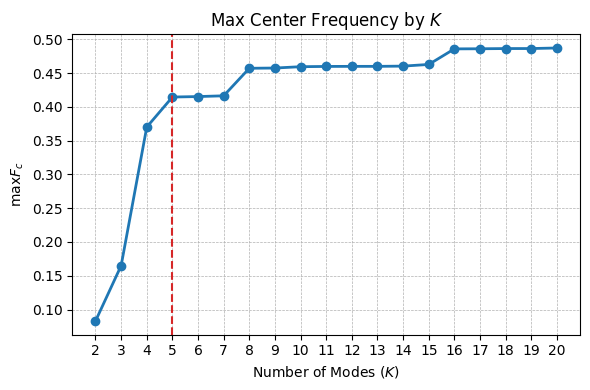

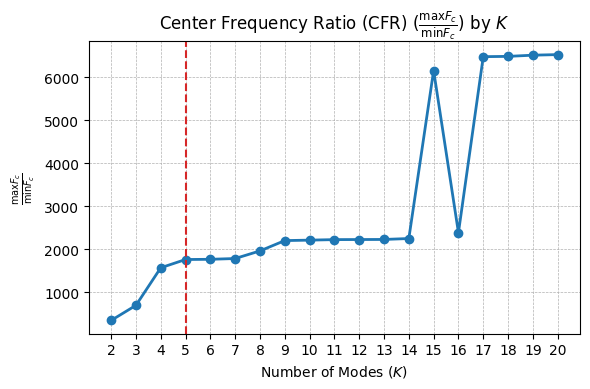

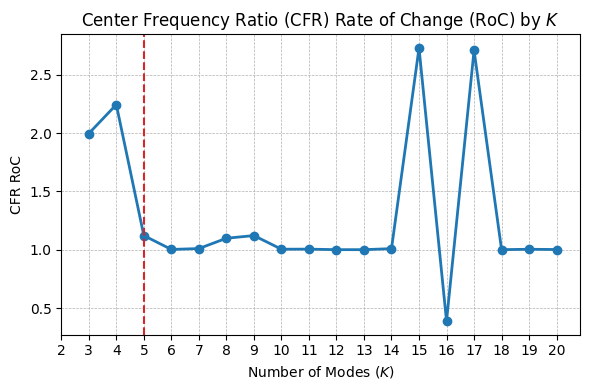

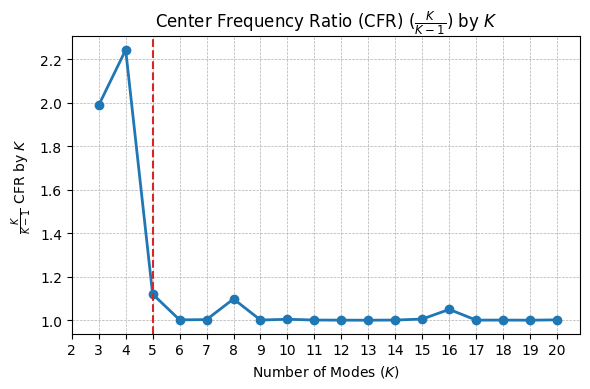

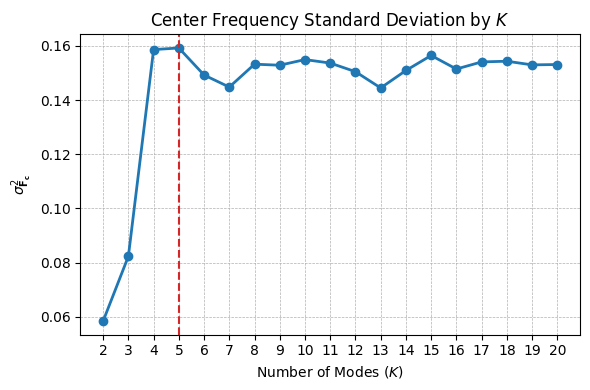

In [15]:
cols = [
    'fc_max',
    'CFR (max/min)',
    'CFR (RoC)',
    'CFR (K/(K-1))',
    'fc_sd'
]
labels = [
    r'$\max F_c$',
    r'$\frac{\max F_c}{\min F_c}$',
    r'CFR RoC',
    r'$\frac{K}{K-1}$ CFR by $K$',
    r'$\sigma^2_{\mathbf{F_c}}$'
]
titles = [
    r'Max Center Frequency by $K$',
    r'Center Frequency Ratio (CFR) ($\frac{\max F_c}{\min F_c}$) by $K$',
    r'Center Frequency Ratio (CFR) Rate of Change (RoC) by $K$',
    r'Center Frequency Ratio (CFR) ($\frac{K}{K-1}$) by $K$',
    r'Center Frequency Standard Deviation by $K$'
]
for col, lab, title in zip(cols, labels, titles):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df_fc['K'], df_fc[col], c='tab:blue', linewidth=2, marker='o')
    ax.set_ylabel(lab)
    ax.set_xlabel(r'Number of Modes ($K$)')
    ax.set_xticks([_ for _ in range(2, 21)])
    ax.grid(linewidth=0.5, linestyle='--')
    ax.axvline(5, color='tab:red', linestyle='--')
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(f"../results/figures/signal_decomposition/{col.lower().replace(' ', '_').replace('/', '_')}.svg")
    plt.show()

### Correlation Analysis

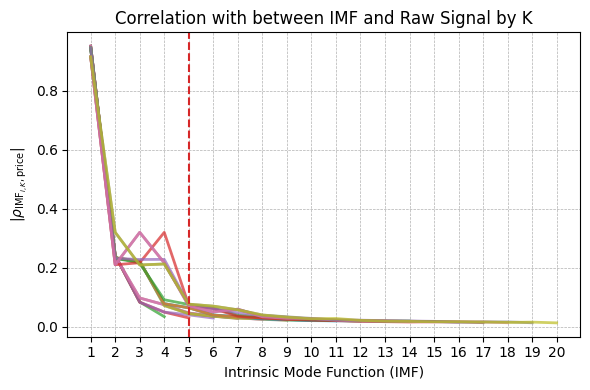

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.lineplot(data=df_corr, x='IMF', y='corr', hue='K', palette='tab10', alpha=0.7, linewidth=2, legend=False)
ax.set_ylabel(r'$|\rho_{\text{IMF}_{i,K},\text{price}}|$')
ax.set_xlabel('Intrinsic Mode Function (IMF)')
ax.set_title('Correlation with between IMF and Raw Signal by K')
ax.set_xticks([_ for _ in range(1, 21)])
ax.grid(linewidth=0.5, linestyle='--')
ax.axvline(5, color='tab:red', linestyle='--')
fig.tight_layout()
fig.savefig(f'../results/figures/signal_decomposition/imf_correlation.svg')
plt.show()

----

## IMF Visualization

In [9]:
df_train_val = pd.read_pickle('../data/processed/df_train_val.pkl')
np_train_val_price = df_train_val['price'].to_numpy()

In [10]:
vmd = VmdTransformer(K=5, alpha=4_000)
vmd.set_random_state(0)

np_train_val_imf = vmd.fit_transform(np_train_val_price)
df_train_val_imf = pd.DataFrame(data=np_train_val_imf, columns=[f'imf{i}' for i in range(1, 6)])
df_train_val_imf['resid'] = np_train_val_price - df_train_val_imf.sum(axis=1)
df_train_val_imf = df_train_val_imf.set_index(df_train_val.index)

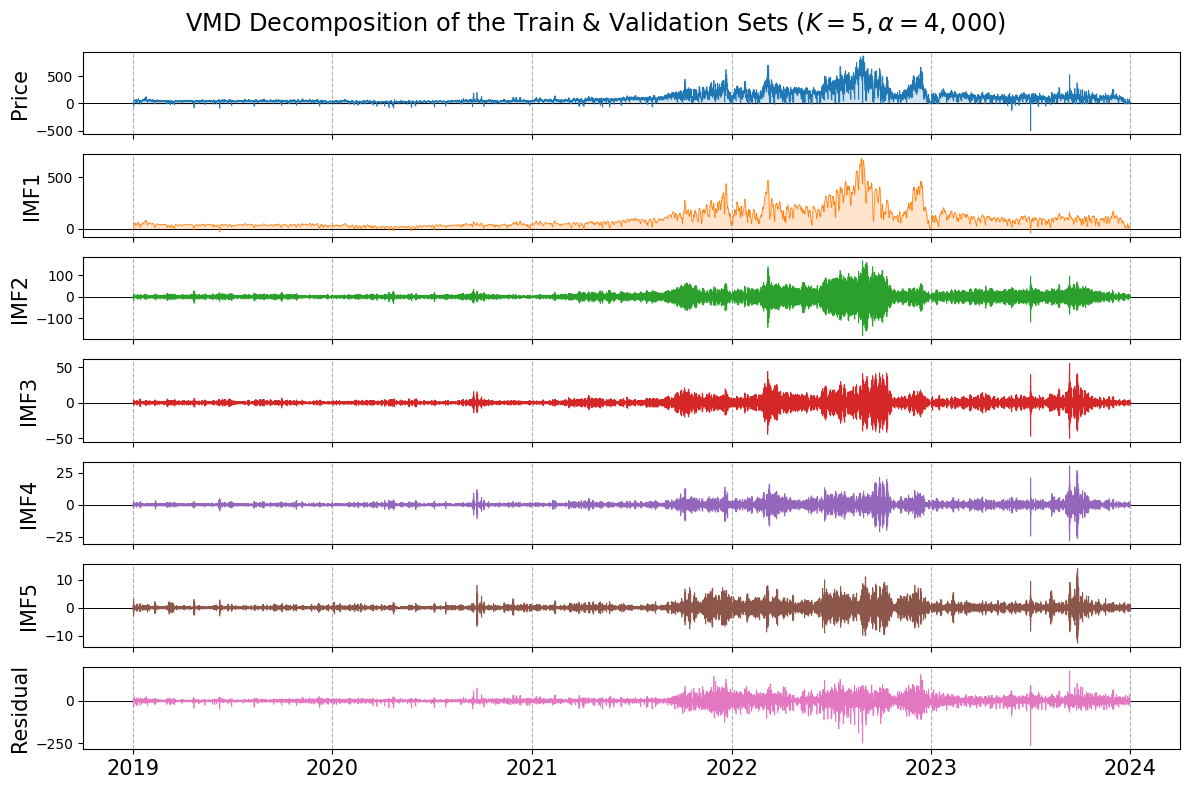

In [14]:
fig, axes = plt.subplots(7, sharex=True, figsize=(12, 8))
colors = plt.colormaps['tab10'].colors

ax = axes[0]
ax.axhline(0, linewidth=0.7, color='black')
ax.plot(df_train_val_imf.index, np_train_val_price, linewidth=0.5, c=colors[0])
ax.fill_between(df_train_val_imf.index, np_train_val_price, color=colors[0], alpha=0.2)
ax.grid(axis='x', linestyle='--')
ax.set_ylabel('Price', fontsize=15)

for i, col in enumerate(df_train_val_imf.columns):
    ax = axes[i+1]
    ax.axhline(0, linewidth=0.7, color='black')
    ax.plot(df_train_val_imf.index, df_train_val_imf[col], linewidth=0.5, c=colors[i+1])
    ax.fill_between(df_train_val_imf.index, df_train_val_imf[col], color=colors[i+1], alpha=0.2)
    ax.grid(axis='x', linestyle='--')
    ax.set_ylabel('Residual' if col=='resid' else col.upper(), fontsize=15)
    ax.tick_params(axis='x', labelsize=15)

fig.suptitle(r'VMD Decomposition of the Train & Validation Sets $(K=5,\alpha=4,000)$', fontsize='xx-large')
plt.tight_layout()
fig.savefig('../results/figures/signal_decomposition/vmd_decomp.svg')
plt.show()

----

## Data Export

In [16]:
df_price = pd.read_pickle('../data/processed/processed_dataset.pkl')
df_price = df_price[['price']]

## 2019 - 2023 is train_val : 2024 is test
## saving train_val and test splits (unstandardized, standardized, scalers)
save_imf_splits(
    df=df_price,
    time_splits=[
        (   # train_start            # train_end
            '2019-01-01 00:00:00+00:00', '2022-12-31 23:00:00+00:00',
            '2023-01-01 00:00:00+00:00', '2023-12-31 23:00:00+00:00'
        )   # val_start                 # val_end
    ],
    f_names=[
        ('df_train_imf', 'df_val_imf')
    ]
)
save_imf_splits(
    df=df_price,
    time_splits=[
        (   # train_val_start            # train_val_end
            '2019-01-01 00:00:00+00:00', '2023-12-31 23:00:00+00:00',
            '2024-01-01 00:00:00+00:00', '2024-12-31 23:00:00+00:00'
        )   # test_start                 # test_end
    ],
    f_names=[
        ('df_train_val_imf', 'df_test_imf')
    ]
)

## saving train and val splits (unstandardized, standardized, scalers)
save_imf_splits(
    df=df_price,
    time_splits=[
        # split 1
        (   # train_start                # train_end
            '2019-01-01 00:00:00+00:00', '2022-12-31 23:00:00+00:00',
            '2023-01-01 00:00:00+00:00', '2023-06-30 23:00:00+00:00'
        ),  # val_start                  # val_end
        # split 2
        (   # train_start                # train_end
            '2019-01-01 00:00:00+00:00', '2023-06-30 23:00:00+00:00',
            '2023-07-01 00:00:00+00:00', '2023-12-31 23:00:00+00:00'
        ),  # val_start                  # val_end
    ],
    f_names=[
        ('df_train1_imf', 'df_val1_imf'),   # split 1
        ('df_train2_imf', 'df_val2_imf')    # split 2
    ]
)